# ⚡ Electrical Fault Detection & Classification
**ABK4ABB3 - Pembelajaran Mesin dan Aplikasi** | Semester Genap 2025/2026 | Telkom University

In [1]:
# Install dependencies (jalankan sekali)
!pip install -q pandas numpy scikit-learn matplotlib seaborn joblib tensorflow gradio

## 📁 Upload Dataset

In [2]:
import os
from google.colab import files

if not os.path.exists('classData.csv'):
    print("Upload file classData.csv dari Kaggle:")
    uploaded = files.upload()
else:
    print("✅ classData.csv sudah ada!")

Upload file classData.csv dari Kaggle:


Saving classData.csv to classData.csv


## 📦 Import Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
from sklearn.dummy import DummyClassifier
import joblib
import warnings
warnings.filterwarnings('ignore')
print("✅ Libraries berhasil diimport")

✅ Libraries berhasil diimport


## 1. Load Dataset & Decode Label

In [4]:
df = pd.read_csv("classData.csv")
print(f"Shape dataset  : {df.shape}")
print(f"Kolom          : {df.columns.tolist()}")
print(f"\nSample data:")
display(df.head())
print(f"\nMissing values:\n{df.isnull().sum()}")

Shape dataset  : (7861, 10)
Kolom          : ['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']

Sample data:


,G,C,B,A,Ia,Ib,Ic,Va,Vb,Vc
0,1,0,0,1,-151.291812,-9.677452,85.800162,0.400750,-0.132935,-0.267815
1,1,0,0,1,-336.186183,-76.283262,18.328897,0.312732,-0.123633,-0.189099
2,1,0,0,1,-502.891583,-174.648023,-80.924663,0.265728,-0.114301,-0.151428
3,1,0,0,1,-593.941905,-217.703359,-124.891924,0.235511,-0.104940,-0.130570
4,1,0,0,1,-643.663617,-224.159427,-132.282815,0.209537,-0.095554,-0.113983



Missing values:
G     0
C     0
B     0
A     0
Ia    0
Ib    0
Ic    0
Va    0
Vb    0
Vc    0
dtype: int64


In [5]:
# Kolom G,C,B,A = label fault type (binary encoded)
# Decode → 1 kolom kelas tunggal
CLASS_LABELS = {0:'Normal', 1:'LG Fault', 2:'LL Fault',
                3:'LLG Fault', 4:'LLL Fault', 5:'LLLG Fault'}

def decode_fault(row):
    combo = (int(row['G']), int(row['C']), int(row['B']), int(row['A']))
    mapping = {
        (0,0,0,0): 0,  # Normal
        (1,0,0,1): 1,  # LG  - Line to Ground
        (0,0,1,1): 2,  # LL  - Line to Line
        (1,0,1,1): 3,  # LLG - Double Line to Ground
        (0,1,1,1): 4,  # LLL - Three Phase
        (1,1,1,1): 5,  # LLLG- Three Phase to Ground
    }
    return mapping.get(combo, -1)

df['fault_class'] = df.apply(decode_fault, axis=1)
df = df[df['fault_class'] != -1].reset_index(drop=True)

print(f"Shape setelah decode: {df.shape}")
print("\nDistribusi kelas:")
for k,v in df['fault_class'].value_counts().sort_index().items():
    print(f"  {k} - {CLASS_LABELS[k]}: {v} sampel")

Shape setelah decode: (6857, 11)

Distribusi kelas:
  0 - Normal: 2365 sampel
  1 - LG Fault: 1129 sampel
  3 - LLG Fault: 1134 sampel
  4 - LLL Fault: 1096 sampel
  5 - LLLG Fault: 1133 sampel


## 2. Exploratory Data Analysis (EDA)

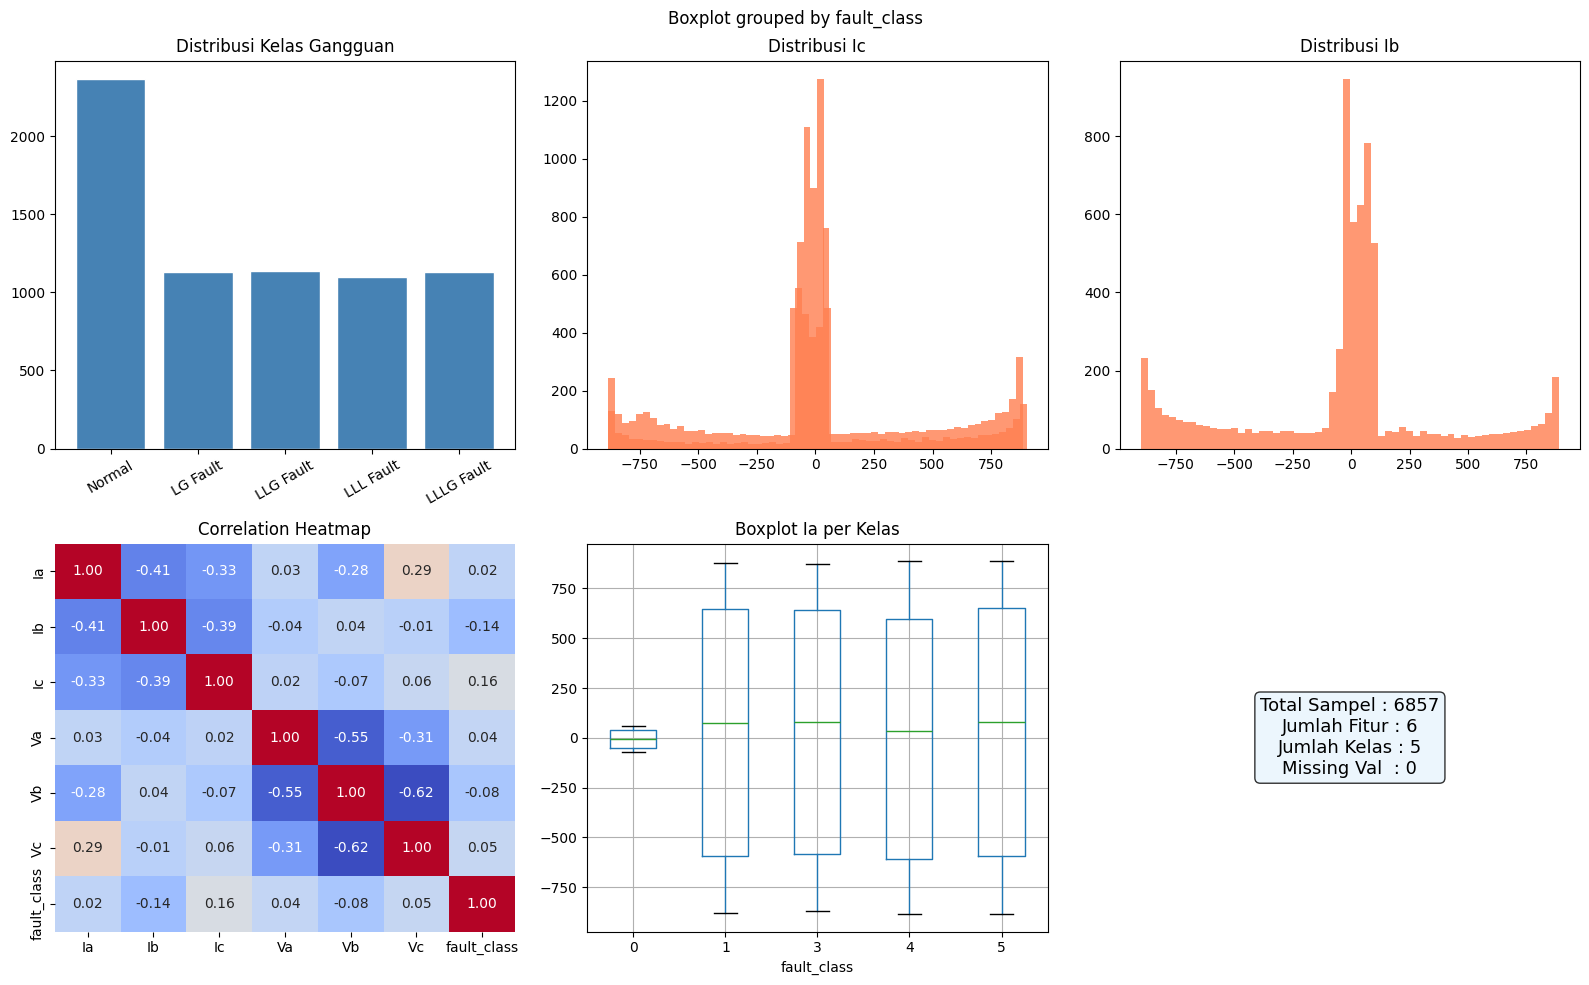

✅ EDA plot disimpan


In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('EDA - Electrical Fault Detection Dataset', fontsize=16)

# Distribusi kelas
class_counts = df['fault_class'].value_counts().sort_index()
axes[0,0].bar([CLASS_LABELS[i] for i in class_counts.index],
              class_counts.values, color='steelblue', edgecolor='white')
axes[0,0].set_title('Distribusi Kelas Gangguan')
axes[0,0].tick_params(axis='x', rotation=30)

# Histogram Ia, Ib, Ic
for idx, col in enumerate(['Ia','Ib','Ic']):
    axes[0, idx+1 if idx < 2 else 1].hist(df[col], bins=60, color='coral', alpha=0.8)
    axes[0, idx+1 if idx < 2 else 1].set_title(f'Distribusi {col}')

# Heatmap korelasi
corr = df[['Ia','Ib','Ic','Va','Vb','Vc','fault_class']].corr()
sns.heatmap(corr, ax=axes[1,0], cmap='coolwarm', annot=True, fmt='.2f', cbar=False)
axes[1,0].set_title('Correlation Heatmap')

# Boxplot
df.boxplot(column='Ia', by='fault_class', ax=axes[1,1])
axes[1,1].set_title('Boxplot Ia per Kelas')

# Info
axes[1,2].axis('off')
axes[1,2].text(0.5, 0.5,
    f"Total Sampel : {len(df)}\nJumlah Fitur : 6\nJumlah Kelas : {df['fault_class'].nunique()}\nMissing Val  : 0",
    ha='center', va='center', fontsize=13, transform=axes[1,2].transAxes,
    bbox=dict(boxstyle='round', facecolor='#e8f4fd', alpha=0.8))

plt.tight_layout()
plt.savefig('eda_plots.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ EDA plot disimpan")

## 3. Preprocessing

In [7]:
feature_cols = ['Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']
X = df[feature_cols].values
y = df['fault_class'].values

# Normalisasi
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split 70/15/15
X_train, X_temp, y_train, y_temp = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')
print("✅ scaler.pkl & feature_cols.pkl disimpan")

Train : 4799 | Val : 1029 | Test : 1029
✅ scaler.pkl & feature_cols.pkl disimpan


## 4. Model 1: Random Forest + Hyperparameter Tuning

In [8]:
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf_base, param_grid_rf, cv=5,
                       scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
print(f"Best params RF : {grid_rf.best_params_}")
print(f"Best CV F1     : {grid_rf.best_score_:.4f}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best params RF : {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1     : 0.8429


[RF] Accuracy : 0.8348
[RF] F1-Score : 0.8348

Kelas yang ada: [np.int64(0), np.int64(1), np.int64(3), np.int64(4), np.int64(5)] → ['Normal', 'LG Fault', 'LLG Fault', 'LLL Fault', 'LLLG Fault']

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       355
    LG Fault       0.99      1.00      0.99       170
   LLG Fault       1.00      0.98      0.99       170
   LLL Fault       0.49      0.50      0.50       164
  LLLG Fault       0.51      0.50      0.50       170

    accuracy                           0.83      1029
   macro avg       0.80      0.80      0.80      1029
weighted avg       0.83      0.83      0.83      1029



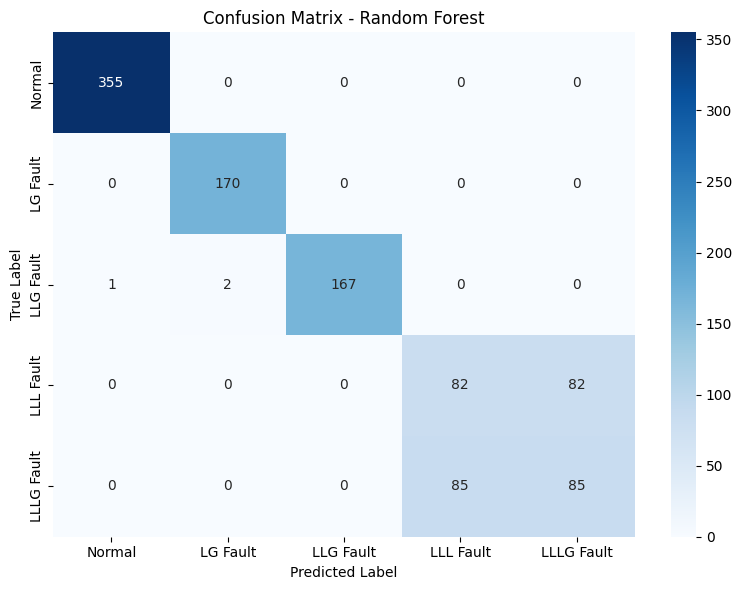

Cross-Val F1: 0.8911 ± 0.0751


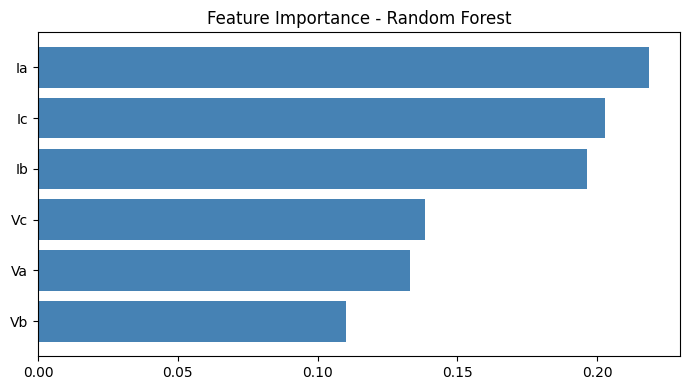

✅ model_rf.pkl disimpan


In [9]:
y_pred_rf = best_rf.predict(X_test)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf  = f1_score(y_test, y_pred_rf, average='weighted')

print(f"[RF] Accuracy : {acc_rf:.4f}")
print(f"[RF] F1-Score : {f1_rf:.4f}")

# Auto-detect kelas yang benar-benar ada di dataset
present_classes = sorted(np.unique(y))
present_labels  = [CLASS_LABELS[c] for c in present_classes]

print(f"\nKelas yang ada: {present_classes} → {present_labels}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred_rf,
                            labels=present_classes,
                            target_names=present_labels))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf, labels=present_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=present_labels, yticklabels=present_labels)
plt.title('Confusion Matrix - Random Forest')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.savefig('cm_rf.png', dpi=150); plt.show()

# Cross-val
cv_rf = cross_val_score(best_rf, X_scaled, y, cv=5, scoring='f1_weighted')
print(f"Cross-Val F1: {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")

# Feature importance
imp_df = pd.DataFrame({'feature': feature_cols, 'importance': best_rf.feature_importances_})
imp_df = imp_df.sort_values('importance', ascending=True)
fig, ax = plt.subplots(figsize=(7,4))
ax.barh(imp_df['feature'], imp_df['importance'], color='steelblue')
ax.set_title('Feature Importance - Random Forest')
plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150); plt.show()

joblib.dump(best_rf, 'model_rf.pkl')
print("✅ model_rf.pkl disimpan")

## 5. Model 2: CNN 1D

In [10]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

n_classes = int(y.max()) + 1
print(f"n_classes: {n_classes}, kelas unik: {np.unique(y)}")

X_train_cnn = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
X_val_cnn   = X_val.reshape(X_val.shape[0],   X_val.shape[1],   1)
X_test_cnn  = X_test.reshape(X_test.shape[0], X_test.shape[1],  1)

y_train_cat = to_categorical(y_train, n_classes)
y_val_cat   = to_categorical(y_val,   n_classes)
y_test_cat  = to_categorical(y_test,  n_classes)

model_cnn = Sequential([
    Conv1D(64,  kernel_size=2, activation='relu', input_shape=(6, 1)),
    BatchNormalization(),
    Conv1D(128, kernel_size=2, activation='relu', padding='same'),
    BatchNormalization(),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dropout(0.2),
    Dense(n_classes, activation='softmax')
])

model_cnn.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model_cnn.summary()

n_classes: 6, kelas unik: [0 1 3 4 5]


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 5, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 64)          │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 5, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 128)         │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        82,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 108,166 (422.52 KB)

 Trainable params: 107,782 (421.02 KB)

 Non-trainable params: 384 (1.50 KB)

In [11]:
callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, monitor='val_accuracy'),
    ReduceLROnPlateau(factor=0.5, patience=5, monitor='val_loss', verbose=1)
]

history = model_cnn.fit(
    X_train_cnn, y_train_cat,
    validation_data=(X_val_cnn, y_val_cat),
    epochs=50, batch_size=32,
    callbacks=callbacks, verbose=1
)

Epoch 1/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7218 - loss: 0.6355 - val_accuracy: 0.4286 - val_loss: 1.3071 - learning_rate: 0.0010
Epoch 2/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7975 - loss: 0.4093 - val_accuracy: 0.7114 - val_loss: 0.7029 - learning_rate: 0.0010
Epoch 3/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7889 - loss: 0.3863 - val_accuracy: 0.8115 - val_loss: 0.3502 - learning_rate: 0.0010
Epoch 4/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.8052 - loss: 0.3468 - val_accuracy: 0.8309 - val_loss: 0.2939 - learning_rate: 0.0010
Epoch 5/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8020 - loss: 0.3318 - val_accuracy: 0.8222 - val_loss: 0.2726 - learning_rate: 0.0010
Epoch 6/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8110 - loss: 0.3190 - val_accuracy: 0.8299 - val_loss: 0.2832 - learning_rate: 0.0010
Epoch 7/50
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8204 - loss: 0.3080 -

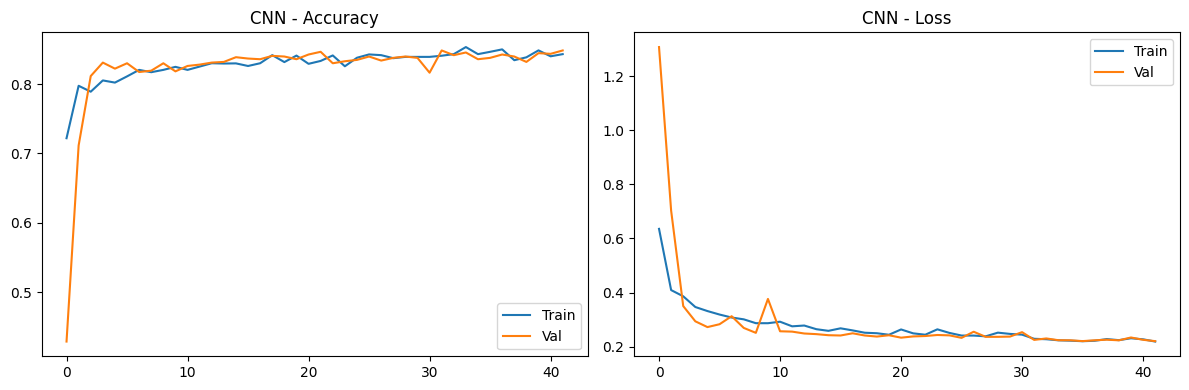

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
[CNN] Accuracy : 0.8416
[CNN] F1-Score : 0.8006
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00       355
    LG Fault       0.96      1.00      0.98       170
   LLG Fault       1.00      0.95      0.98       170
   LLL Fault       0.92      0.07      0.12       164
  LLLG Fault       0.52      0.99      0.68       170

    accuracy                           0.84      1029
   macro avg       0.88      0.80      0.75      1029
weighted avg       0.90      0.84      0.80      1029



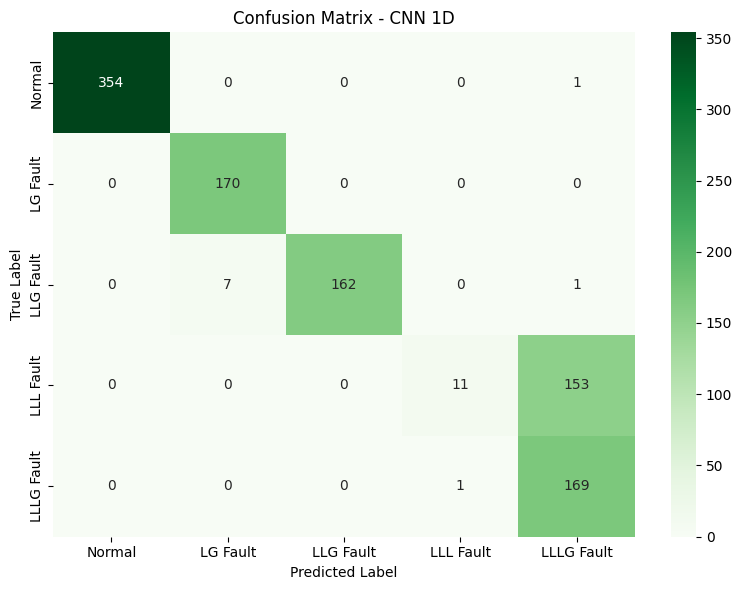

✅ model_cnn.h5 disimpan


In [12]:
# Learning curves
fig, axes = plt.subplots(1, 2, figsize=(12,4))
axes[0].plot(history.history['accuracy'],     label='Train')
axes[0].plot(history.history['val_accuracy'], label='Val')
axes[0].set_title('CNN - Accuracy'); axes[0].legend()
axes[1].plot(history.history['loss'],     label='Train')
axes[1].plot(history.history['val_loss'], label='Val')
axes[1].set_title('CNN - Loss'); axes[1].legend()
plt.tight_layout(); plt.savefig('learning_curve_cnn.png', dpi=150); plt.show()

y_pred_cnn = np.argmax(model_cnn.predict(X_test_cnn), axis=1)
acc_cnn = accuracy_score(y_test, y_pred_cnn)
f1_cnn  = f1_score(y_test, y_pred_cnn, average='weighted')

print(f"[CNN] Accuracy : {acc_cnn:.4f}")
print(f"[CNN] F1-Score : {f1_cnn:.4f}")

present_classes = sorted(np.unique(y))
present_labels  = [CLASS_LABELS[c] for c in present_classes]

print(classification_report(y_test, y_pred_cnn,
                            labels=present_classes,
                            target_names=present_labels))

cm_cnn = confusion_matrix(y_test, y_pred_cnn, labels=present_classes)
plt.figure(figsize=(8,6))
sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=present_labels, yticklabels=present_labels)
plt.title('Confusion Matrix - CNN 1D')
plt.ylabel('True Label'); plt.xlabel('Predicted Label')
plt.tight_layout(); plt.savefig('cm_cnn.png', dpi=150); plt.show()

model_cnn.save('model_cnn.h5')
print("✅ model_cnn.h5 disimpan")

## 6. Perbandingan Model

        Model  Accuracy F1-Score (weighted)
     Baseline    0.3450                   -
Random Forest    0.8348              0.8348
       CNN 1D    0.8416              0.8006


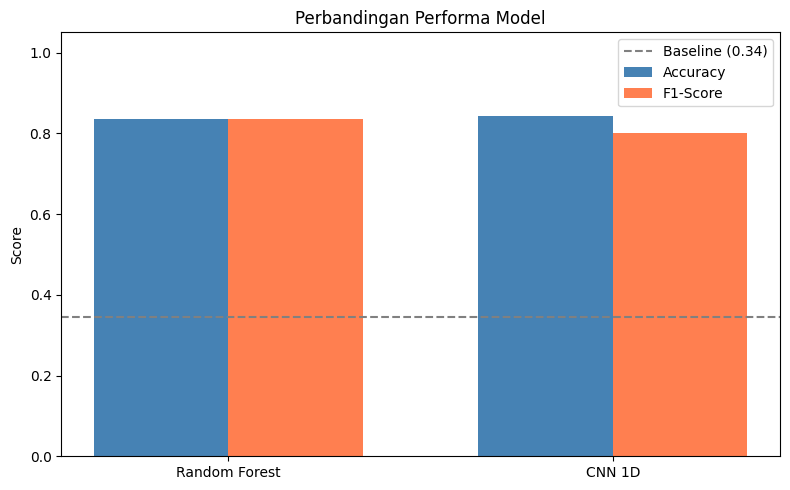


✅ Semua selesai!


In [13]:
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
acc_dummy = accuracy_score(y_test, dummy.predict(X_test))

comparison = pd.DataFrame({
    'Model':               ['Baseline', 'Random Forest', 'CNN 1D'],
    'Accuracy':            [round(acc_dummy,4), round(acc_rf,4), round(acc_cnn,4)],
    'F1-Score (weighted)': ['-', round(f1_rf,4), round(f1_cnn,4)]
})
print(comparison.to_string(index=False))

fig, ax = plt.subplots(figsize=(8,5))
x = np.arange(2); w = 0.35
ax.bar(x-w/2, [acc_rf, acc_cnn], w, label='Accuracy',  color='steelblue')
ax.bar(x+w/2, [f1_rf,  f1_cnn],  w, label='F1-Score',  color='coral')
ax.axhline(y=acc_dummy, color='gray', linestyle='--', label=f'Baseline ({acc_dummy:.2f})')
ax.set_xticks(x); ax.set_xticklabels(['Random Forest','CNN 1D'])
ax.set_ylim(0, 1.05); ax.set_ylabel('Score')
ax.set_title('Perbandingan Performa Model'); ax.legend()
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150); plt.show()

print("\n✅ Semua selesai!")

## 📥 Download Model & Artefak

In [14]:
from google.colab import files
import zipfile, os

# Zip semua output
with zipfile.ZipFile('hasil_training.zip', 'w') as zf:
    for f in ['model_rf.pkl','model_cnn.h5','scaler.pkl','feature_cols.pkl',
              'eda_plots.png','cm_rf.png','cm_cnn.png',
              'learning_curve_cnn.png','feature_importance.png','model_comparison.png']:
        if os.path.exists(f):
            zf.write(f)
            print(f"  ✅ {f}")

files.download('hasil_training.zip')
print("\n📦 Download hasil_training.zip")

  ✅ model_rf.pkl
  ✅ model_cnn.h5
  ✅ scaler.pkl
  ✅ feature_cols.pkl
  ✅ eda_plots.png
  ✅ cm_rf.png
  ✅ cm_cnn.png
  ✅ learning_curve_cnn.png
  ✅ feature_importance.png
  ✅ model_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


📦 Download hasil_training.zip


In [ ]:
!pip install gradio -q

app_code = '''
import gradio as gr
import numpy as np
import joblib

scaler = joblib.load("/content/scaler.pkl")
feature_cols = joblib.load("/content/feature_cols.pkl")
model_rf = joblib.load("/content/model_rf.pkl")

CLASS_LABELS = {0:"Normal", 1:"LG Fault", 2:"LL Fault",
                3:"LLG Fault", 4:"LLL Fault", 5:"LLLG Fault"}

FAULT_DESC = {
    0: "Sistem beroperasi normal, tidak ada gangguan terdeteksi.",
    1: "Line-to-Ground Fault: Gangguan satu fasa ke tanah.",
    2: "Line-to-Line Fault: Gangguan antar dua fasa.",
    3: "Double Line-to-Ground Fault: Gangguan dua fasa ke tanah.",
    4: "Three-Phase Fault: Gangguan tiga fasa serentak.",
    5: "Three-Phase-to-Ground Fault: Gangguan tiga fasa ke tanah."
}

def predict(*args):
    x = np.array(args).reshape(1,-1)
    x_scaled = scaler.transform(x)
    pred = model_rf.predict(x_scaled)[0]
    proba = model_rf.predict_proba(x_scaled)[0]

    classes = model_rf.classes_
    prob_table = "\\n\\n**Probabilitas per Kelas:**\\n"
    for i, cls in enumerate(classes):
        bar = "█" * int(proba[i] * 20)
        prob_table += f"- {CLASS_LABELS[cls]}: {bar} {proba[i]*100:.1f}%\\n"

    status = "🟢" if pred == 0 else "🔴"
    result  = f"## {status} Prediksi: {CLASS_LABELS[pred]}\\n\\n"
    result += f"**Konfidiensi:** {proba[list(classes).index(pred)]*100:.1f}%\\n\\n"
    result += f"**Deskripsi:** {FAULT_DESC[pred]}"
    result += prob_table
    return result

inputs = [gr.Number(label=c, value=0) for c in feature_cols]
demo = gr.Interface(
    fn=predict,
    inputs=inputs,
    outputs=gr.Markdown(),
    title="⚡ Electrical Fault Detection & Classification",
    description="Masukkan nilai arus (Ia, Ib, Ic) dan tegangan (Va, Vb, Vc) untuk mendeteksi jenis gangguan jaringan listrik.",
    examples=[
        [0, 0, 0, 0.4, -0.2, -0.2],
        [-151.29, -9.68, 85.80, 0.40, -0.13, -0.27],
        [-300, -300, 100, 0.1, 0.1, -0.2],
    ],
    theme=gr.themes.Soft()
)
demo.launch(share=True)
'''

with open("app.py", "w") as f:
    f.write(app_code)

!python app.py

* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://a35eaf1cf068685c6a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
